In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sc
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [32]:
ROOT = '../data/processed/'
PATH_UNET_MLP_MODEL = ROOT+'2025_results_noise0_unetmlp/'
PATH_BASELINE =  ROOT+'2025_results_baseline/'

In [33]:
# Variables
variable_names={"temperature",
            "pH",
            "sodium",
            "glucose"}

In [34]:
for value in variable_names:
    df= pd.read_csv(PATH_UNET_MLP_MODEL+"model_unet_mlp_model_{}_noise0_2025.csv".format(value))
    print(value.upper())

GLUCOSE
PH
TEMPERATURE
SODIUM


glucose
Baseline MAE: 0.04970527343749999
Baseline SD: 0.04081365452907865
U-Net MAE: 0.01871666666666667
U-Net SD: 0.025910642386650487
U statistic: 48461.5
P-value 4.912648804058396e-29
Reject null hypothesis: Significant difference between groups.


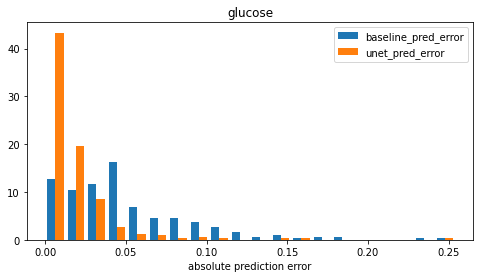

pH
Baseline MAE: 0.41334677419354826
Baseline SD: 0.27276713672414965
U-Net MAE: 0.4154833333333333
U-Net SD: 0.3554963076070161
U statistic: 15504.5
P-value 0.2559561138354744
Fail to reject null hypothesis: No significant difference.


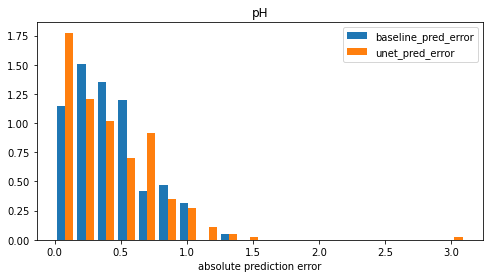

temperature
Baseline MAE: 0.5822844290657435
Baseline SD: 0.3483911083245688
U-Net MAE: 0.45502272727272736
U-Net SD: 0.37889742487166633
U statistic: 39419.0
P-value 1.736039216095387e-06
Reject null hypothesis: Significant difference between groups.


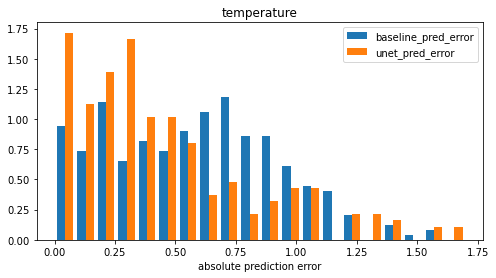

sodium
Baseline MAE: 1.27878515625
Baseline SD: 1.2104550109159522
U-Net MAE: 0.8565124999999999
U-Net SD: 0.7013605883165591
U statistic: 36216.5
P-value 0.00028515797161487874
Reject null hypothesis: Significant difference between groups.


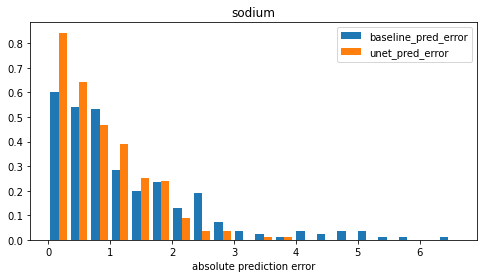

In [35]:
# Variable
for value in variable_names:
    
    # Baseline
    df_baseline = pd.read_csv(PATH_BASELINE+"model_baseline_{}_noise0_2025-04-07.csv".format(value))
    
    # UNET
    df_unet_mlp= pd.read_csv(PATH_UNET_MLP_MODEL+"model_unet_mlp_model_{}_noise0_2025.csv".format(value))
    
    
    if value=='temperature':
        df_baseline = df_baseline[df_baseline['target_array_real'].between(35.5, 39)]
        df_unet_mlp = df_unet_mlp[df_unet_mlp['target_array_real'].between(35.5, 39)]  

    # Errors
    df_baseline['pred_error']=df_baseline['target_array_real']-df_baseline['pred_array_offset']
    baseline_pred_error = np.abs(df_baseline['pred_error'].to_numpy())
    
    df_unet_mlp['pred_error']=df_unet_mlp['target_array_real']-df_unet_mlp['pred_array_real']
    unet_pred_error = np.abs(df_unet_mlp['pred_error'].to_numpy())
    
    # print MAE
    print(value)
    print('Baseline MAE:',np.mean(baseline_pred_error))
    print('Baseline SD:',np.std(baseline_pred_error))
    
    print('U-Net MAE:',np.mean(unet_pred_error))
    print('U-Net SD:',np.std(unet_pred_error))
    
    # Statistical Test
    # Perform the test
    statistic, p_value = mannwhitneyu(baseline_pred_error, unet_pred_error, alternative='greater')

#     print(f"U statistic: {statistic:.4f}")
#     print(f"P-value: {p_value:.4f}")
    print("U statistic:", statistic)
    print("P-value", p_value)

    if p_value < 0.05:
        print("Reject null hypothesis: Significant difference between groups.")
    else:
        print("Fail to reject null hypothesis: No significant difference.")
    
    
    # Plot for Variable 
    plt.figure(figsize=(8, 4))
    plt.title(value)
    plt.xlabel('absolute prediction error')
    plt.hist([baseline_pred_error, unet_pred_error], bins=20, label=["baseline_pred_error","unet_pred_error"], density=True)
    plt.legend(loc="upper right")
    plt.show()
    
#     print(len(unet_pred_error))
#     print(len(baseline_pred_error))
    


Text(0, 0.5, 'Temperature Model Prediction')

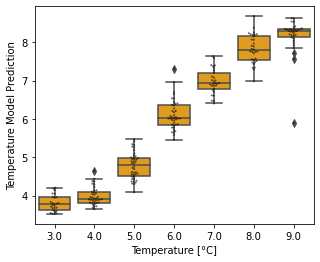

In [28]:
value='pH'
# Baseline
# df_results_complete = pd.read_csv(PATH_BASELINE+"model_baseline_{}_noise0_2025-04-07.csv".format(value))
# ylabel='pred_array_offset'
# Unet
df_results_complete= pd.read_csv(PATH_UNET_MLP_MODEL+"model_unet_mlp_model_{}_noise0_2025.csv".format(value))
ylabel='pred_array_real'

# df_results_complete = df_results_complete[df_results_complete['target_array_real'].between(35.5, 39)]

# Plot violin
fig = plt.figure(figsize=(5, 4))
sns.boxplot(
    data=df_results_complete,
    x="target_array_real",
    y=ylabel,
    # width=1.1
    color='orange',
)
sns.swarmplot(
    data=df_results_complete,
    x="target_array_real",
    y=ylabel,
    size=2,
    color='black',
    alpha=0.6,
    # width=1.1
    # color='thistle',
)


plt.xlabel('Temperature [°C]')
plt.ylabel('Temperature Model Prediction')
